# Chain Summary Bars

Bar-style chain comparison plots, following the region-split notebook style but using reusable helpers from `plotting_tools.py`.


In [209]:
import os
import sys
import itertools
from pathlib import Path

# This notebook only loads/plots saved results; keep JAX from probing or reserving GPU memory.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['MPICH_GPU_SUPPORT_ENABLED'] = '0'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from desilike.samples import Chain

main_dir = Path('/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/main')
if str(main_dir) not in sys.path:
    sys.path.insert(0, str(main_dir))

from helper import REDSHIFT_BIN_TRACER
from cat_tools import parse_zerr_name
from fit_tools import LikelihoodBuilder, get_fits_fn
from plotting_tools import PLANCK_COSMOLOGY, make_key, chain_fit_results

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
FITS_DIR = Path('/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits')

%load_ext autoreload
%autoreload 2

save_fig = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
## Fiducial settings
domain = 'altmtl'
version= 'AbacusHF-v2'
mockids = list(range(25))
cov_version = 'holi-v3'

cosmo_params = 'base'
theory_model = 'folpsD'
prior_basis = 'physical_aap'

KRANGES = {
    'mesh2': [
        {'ells': 0, 'k': [0.02, 0.300, 0.005]},
        {'ells': 2, 'k': [0.02, 0.300, 0.005]},
        # {'ells': 4, 'k': [0.02, 0.300, 0.005]},
    ],
    'mesh3': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.005]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.08, 0.005]},
    ],
}

step = 2
analysis_settings = {
    'smooth_scale_1D': 0.8,
    'smooth_scale_2D': 0.8,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

In [207]:
TRACERS = ['LRG1', 'LRG2', 'LRG3', 'QSO1'][:3]
ZERRS = [None, 'verr_nonparam']
STATS = [['mesh2'], ['mesh2', 'mesh3']]

params = ['H0', 'Omega_m', 'sigma8_m']

In [211]:
chains_by_key = {}

for tracer, zerr, stats in itertools.product(TRACERS, ZERRS, STATS):
    zrange = REDSHIFT_BIN_TRACER[tracer]
    use_dv, z_evol = parse_zerr_name(zerr)
    observables = [{'stat': {'kind': stat, 'select': KRANGES[f"{stat}"]},
                'theory': {'model': 'folpsD', 'prior_basis': "physical_aap"},
                } for stat in stats]
    data_args = {'version': version, 'domain':domain, 'tracer':tracer, 'zrange': zrange, 
                 'mock_ids': mockids, 'region': 'ALL', "use_dv": use_dv, "z_evol": z_evol}
    data_args['mock_id'] = mockids[0]
    covariance_args = {'source': 'mock', 'version': cov_version, 'mock_ids': range(1000),
                        'corrections': ['hartlap', 'percival'], 'rescale': False}
    cosmology_args = {'model': cosmo_params, 'template': 'direct'}
    fit_args = dict(observables=observables, catalog=data_args, covariance=covariance_args,
                    cosmology=cosmology_args, cache_dir=FITS_DIR / '_cache')
    builder = LikelihoodBuilder(**fit_args)

    stat_label = '+'.join(stats)
    chain_key = f"{tracer}_{stat_label}_{use_dv}"
    chain_fn = builder.get_fits_fn(fits_dir=FITS_DIR, kind='chain', ichain=0)
    if not chain_fn.is_file():
        print(f"Chain file not found: {chain_fn}")
        continue
    chain = Chain.load(chain_fn).remove_burnin(0.5)[::step]
    fit_results = chain_fit_results(chain, params=params)
    for param in fit_results:
        try:
            fit_results[param]['std'] = float(chain.std(params=param))
        except AttributeError:
            pass
    chain = chain.to_getdist(settings=analysis_settings)

    chains_by_key[chain_key] = {
        'chain': chain,
        'args': [data_args, covariance_args, cosmology_args],
        'fit_results': fit_results,
        'stats': list(stats),
        'stat_label': stat_label,
    }


[013658.14]  06-08 06:08  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2-863970d7/chain_0.npy.


Removed no burn in
[013658.28]  06-08 06:08  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2+LRG1-z0.4-0.6-mean25-S3-049dea16/chain_0.npy.
Removed no burn in
[013658.58]  06-08 06:08  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2-de651060/chain_0.npy.
Removed no burn in
[013658.78]  06-08 06:08  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2+LRG1-z0.4-0.6-mean25-S3-37538776/chain_0.npy.
Removed no burn in
[013659.09]  06-08 06:08  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG2-z0.6-0.8-mean25-S2-084d648c/chain_0.npy.
Removed no burn in
[013659.35]  06-08 06:08  Chain                      

In [212]:
chains_by_key.keys()

dict_keys(['LRG1_mesh2_None', 'LRG1_mesh2+mesh3_None', 'LRG1_mesh2_verr_nonparam', 'LRG1_mesh2+mesh3_verr_nonparam', 'LRG2_mesh2_None', 'LRG2_mesh2+mesh3_None', 'LRG2_mesh2_verr_nonparam', 'LRG2_mesh2+mesh3_verr_nonparam', 'LRG3_mesh2_None', 'LRG3_mesh2_verr_nonparam'])

In [213]:
from plotting_tools import PARAM_LABELS


def _fit_label_from_args(data_args):
    use_dv = data_args.get('use_dv', 'None')
    if use_dv in [None, False, 'None', 'False']:
        label = 'standard'
    else:
        label = str(use_dv)
    if data_args.get('z_evol', False):
        label = f'{label} + zevol'
    return label

def _stat_label_from_result(result):
    if 'stat_label' in result:
        return str(result['stat_label'])
    if 'stats' in result:
        return '+'.join(result['stats'])
    return 'unknown'

def _stat_cmap(stat_label, stat_cmaps=None):
    stat_cmaps = stat_cmaps
    return plt.colormaps[stat_cmaps.get(str(stat_label), 'viridis')]

def build_fit_summary_table(chains_dict, params):
    rows = []
    for key, result in chains_dict.items():
        data_args = result.get('args', [{}])[0]
        fit_results = result.get('fit_results', {})
        fit_label = _fit_label_from_args(data_args)
        stat_label = _stat_label_from_result(result)
        row = {
            'key': str(key),
            'tracer': str(data_args.get('tracer', str(key).split('_')[0])),
            'fit_label': fit_label,
            'stat_label': stat_label,
            'comparison_label': f'{fit_label}, {stat_label}',
            'bestfit': fit_results,
        }
        for param in params:
            summary = fit_results.get(param, {})
            row[param] = summary.get('mean', np.nan)
        rows.append(row)
    return pd.DataFrame(rows)


def _summary_yerr(summary, center='mean', error='std', low='q16', high='q84'):
    if not summary or center not in summary:
        return None
    y = float(summary[center])
    if error in summary:
        return float(summary[error])
    if low in summary and high in summary:
        return np.array([[max(0.0, y - float(summary[low]))], [max(0.0, float(summary[high]) - y)]])
    return None


def _display_comparison_label(fit_label, stat_label, fit_label_display=None, stat_label_display=None):
    fit_label_display = fit_label_display or {}
    stat_label_display = stat_label_display or {}
    return f'{fit_label_display.get(fit_label, fit_label)}, {stat_label_display.get(stat_label, stat_label)}'


def _combo_style(fit_index, nfit, cmap):
    # Stat selects the color family; zerr selects shade within that family.
    fit_norm = 0.0 if nfit <= 1 else fit_index / (nfit - 1)
    shade = 0.7 - 0.3 * fit_norm
    color = cmap(shade)
    return color

def plot_chain_comparison(chains_dict, params=('H0', 'Omega_m', 'sigma8_m'), tracers=None,
                          fit_labels=None, stat_labels=None, center='mean', error='std',
                          low='q16', high='q84', markers=('o', 's', 'D', '^', 'v'),
                          offset_width=0.12, fit_label_display=None, stat_label_display=None,
                          stat_cmaps=None):
    table = build_fit_summary_table(chains_dict, params=params)
    if table.empty:
        raise ValueError('No chain results available to plot')

    if tracers is None:
        tracers = list(table['tracer'].dropna().unique())
    else:
        tracers = [str(tracer) for tracer in tracers]
        table = table.loc[table['tracer'].isin(tracers)]

    if fit_labels is None:
        fit_labels = list(table['fit_label'].dropna().unique())
    else:
        fit_labels = [str(label) for label in fit_labels]
        table = table.loc[table['fit_label'].isin(fit_labels)]

    if stat_labels is None:
        stat_labels = list(table['stat_label'].dropna().unique())
    else:
        stat_labels = [str(label) for label in stat_labels]
        table = table.loc[table['stat_label'].isin(stat_labels)]

    comparison_labels = [
        f'{fit_label}, {stat_label}'
        for stat_label in stat_labels
        for fit_label in fit_labels
    ]
    comparison_labels = [label for label in comparison_labels if label in set(table['comparison_label'])]

    params = [str(param) for param in params if str(param) in table.columns]
    if not params:
        raise ValueError('None of the requested parameters are available')
    if not tracers:
        raise ValueError('No tracers found')
    if not comparison_labels:
        raise ValueError('No fit/stat combinations found')

    fig, axes = plt.subplots(len(params), 1, figsize=(8.0, 1.5 * len(params) + 0.8), sharex=True)
    axes = np.atleast_1d(axes)
    x_positions = np.arange(len(tracers))
    offsets = np.linspace(-offset_width, offset_width, len(comparison_labels))
    points_plotted = 0

    for ax, param in zip(axes, params):
        for icombo, comparison_label in enumerate(comparison_labels):
            fit_label, stat_label = comparison_label.split(', ', 1)
            ifit = fit_labels.index(fit_label)
            istat = stat_labels.index(stat_label)
            display_label = _display_comparison_label(
                fit_label, stat_label,
                fit_label_display=fit_label_display,
                stat_label_display=stat_label_display,
            )

            for itracer, tracer in enumerate(tracers):
                rows = table.loc[
                    (table['tracer'] == tracer)
                    & (table['fit_label'] == fit_label)
                    & (table['stat_label'] == stat_label)
                ]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                summary = row['bestfit'].get(param, {})
                if center not in summary:
                    continue

                x = x_positions[itracer] + offsets[icombo]
                cmap = _stat_cmap(stat_label, stat_cmaps=stat_cmaps)
                color = _combo_style(ifit, len(fit_labels), cmap)
                marker = markers[ifit % len(markers)]

                y = float(summary[center])
                yerr = _summary_yerr(summary, center=center, error=error, low=low, high=high)

                ax.errorbar(
                    x, y, yerr=yerr,
                    color=color,
                    marker=marker,
                    markerfacecolor=color,
                    markeredgecolor=color,
                    markeredgewidth=1.1,
                    ls='',
                    capsize=2.5,
                    lw=1.0,
                    ms=5.5,
                    label=display_label if itracer == 0 else None,
                )
                points_plotted += 1
        true_values = PLANCK_COSMOLOGY
        ax.axhline(true_values.get(param, np.nan), color='gray', ls='--', lw=1.0, label='Planck' if points_plotted == 0 else None)
        
        ax.set_ylabel(PARAM_LABELS.get(param, param), fontsize=14)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(tracers, fontsize=13)
        ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
        ax.grid(axis='y', alpha=0.2)

    if points_plotted == 0:
        raise ValueError('No matching fit-summary points found to plot')
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), fontsize=12,
                   ncol=min(len(comparison_labels), 4), frameon=False)
    fig.tight_layout()
    return fig

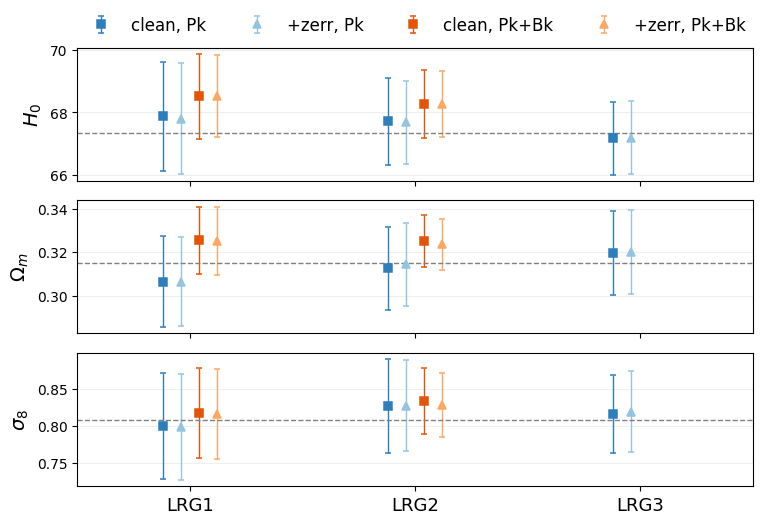

In [214]:
fig = plot_chain_comparison(
    chains_by_key,
    params=params,
    tracers=TRACERS,
    fit_labels=['standard', 'verr_nonparam'],
    stat_labels=['mesh2', 'mesh2+mesh3'],
    fit_label_display={
        'standard': 'clean',
        'verr_nonparam': '+zerr',
    },
    stat_label_display={
        'mesh2': 'Pk',
        'mesh2+mesh3': 'Pk+Bk',
    },
    stat_cmaps={
        'mesh2': 'Blues',
        'mesh2+mesh3': 'Oranges',
    },
    markers=('s', '^'),
)

if save_fig == True:
    fig.savefig(OVERLEAF_DIR+f'/plot_fits_comparison.pdf', bbox_inches='tight')